# Customer Churn Prediction System
**Data Science Task #10 — Customer Churn Prediction System**

This notebook covers the full pipeline:
1. Data Understanding & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (encoding, scaling)
4. Machine Learning Model Development (Logistic Regression, Decision Tree, Random Forest)
5. Model Evaluation & Feature Importance
6. Saving the final model for the Streamlit dashboard

The dataset follows the structure of a standard telecom customer churn dataset
(demographics, account info, and subscribed services), with ~3,000 customer records.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import pickle, json

sns.set_theme(style="whitegrid")
%matplotlib inline

BASE_DIR = Path.cwd().parent
DATA_RAW = BASE_DIR / "data" / "raw" / "telco_churn_raw.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed" / "telco_churn_cleaned.csv"
MODELS_DIR = BASE_DIR / "models"
CHARTS_DIR = BASE_DIR / "charts"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load & Understand the Data

In [2]:
df = pd.read_csv(DATA_RAW)
print("Shape:", df.shape)
df.head()

Shape: (3025, 21)


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService       OnlineSecurity         OnlineBackup     DeviceProtection          TechSupport          StreamingTV      StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
0  CUST-10000    Male              0     Yes         No      13          Yes               Yes             DSL                   No                   No                  Yes                   No                  Yes                  Yes  Month-to-month               No           Electronic check           66.22        852.53   Yes
1  CUST-10001  Female              1     Yes         No      26          Yes               Yes              No  No internet service  No internet service  No internet service  No internet service  No internet service  No internet service        One year              Yes           Electronic check           30.70        821.34    No
2

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3025 non-null   str    
 1   gender            3025 non-null   str    
 2   SeniorCitizen     3025 non-null   int64  
 3   Partner           3025 non-null   str    
 4   Dependents        3025 non-null   str    
 5   tenure            3025 non-null   int64  
 6   PhoneService      3025 non-null   str    
 7   MultipleLines     3010 non-null   str    
 8   InternetService   3025 non-null   str    
 9   OnlineSecurity    3025 non-null   str    
 10  OnlineBackup      3025 non-null   str    
 11  DeviceProtection  3025 non-null   str    
 12  TechSupport       3025 non-null   str    
 13  StreamingTV       3025 non-null   str    
 14  StreamingMovies   3025 non-null   str    
 15  Contract          3025 non-null   str    
 16  PaperlessBilling  3025 non-null   str    
 17  Paymen

In [4]:
df.describe(include='all').T

                   count unique               top  freq         mean          std   min     25%      50%      75%      max
customerID          3025   3000        CUST-10048     2          NaN          NaN   NaN     NaN      NaN      NaN      NaN
gender              3025      2              Male  1519          NaN          NaN   NaN     NaN      NaN      NaN      NaN
SeniorCitizen     3025.0    NaN               NaN   NaN     0.158678     0.365436   0.0     0.0      0.0      0.0      1.0
Partner             3025      2                No  1530          NaN          NaN   NaN     NaN      NaN      NaN      NaN
Dependents          3025      2                No  2125          NaN          NaN   NaN     NaN      NaN      NaN      NaN
tenure            3025.0    NaN               NaN   NaN    36.570248    21.045894   0.0    18.0     37.0     55.0     72.0
PhoneService        3025      2               Yes  2730          NaN          NaN   NaN     NaN      NaN      NaN      NaN
MultipleLines   

## 3. Data Cleaning & Preprocessing
- Remove duplicate records
- Convert `TotalCharges` to numeric (blank strings for new customers)
- Impute missing values
- Handle inconsistent categories

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 24
Shape after dropping duplicates: (3001, 21)


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing MultipleLines:", df["MultipleLines"].isna().sum())
df["MultipleLines"] = df["MultipleLines"].fillna(df["MultipleLines"].mode()[0])

print("\nRemaining nulls:\n", df.isna().sum()[df.isna().sum() > 0])

Missing TotalCharges: 40
Missing MultipleLines: 15

Remaining nulls:
 Series([], dtype: int64)


In [7]:
df.to_csv(DATA_PROCESSED, index=False)
print("Cleaned dataset saved. Final shape:", df.shape)

Cleaned dataset saved. Final shape: (3001, 21)


## 4. Exploratory Data Analysis

In [8]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.681773
Yes    0.318227

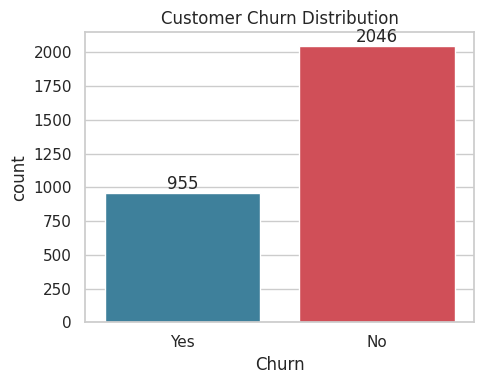

In [9]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x="Churn", data=df, hue="Churn", palette=["#2E86AB","#E63946"], legend=False)
ax.set_title("Customer Churn Distribution")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

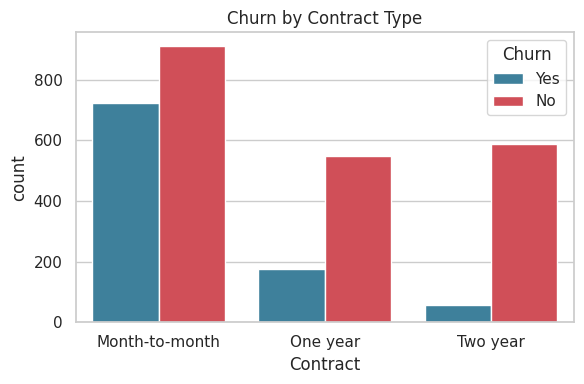

In [10]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Contract", hue="Churn", data=df, palette=["#2E86AB","#E63946"])
ax.set_title("Churn by Contract Type")
plt.tight_layout()
plt.show()

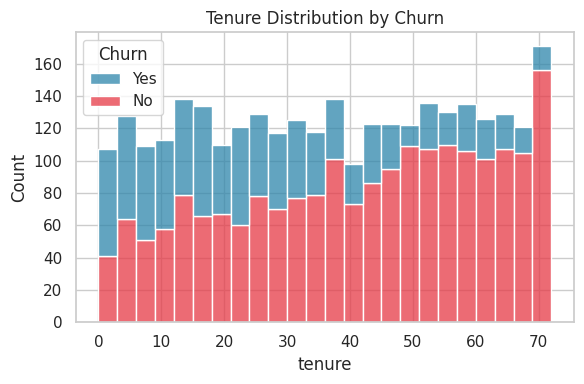

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=24, palette=["#2E86AB","#E63946"])
plt.title("Tenure Distribution by Churn")
plt.tight_layout()
plt.show()

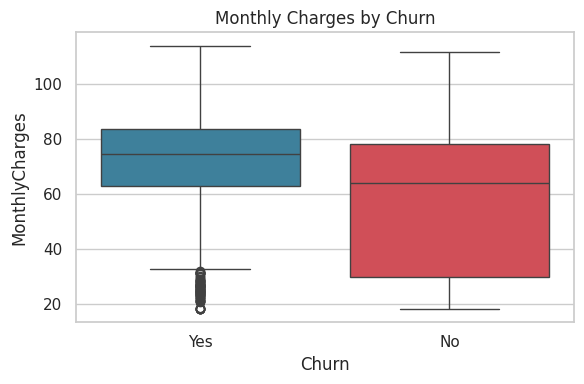

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette=["#2E86AB","#E63946"], legend=False)
plt.title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()

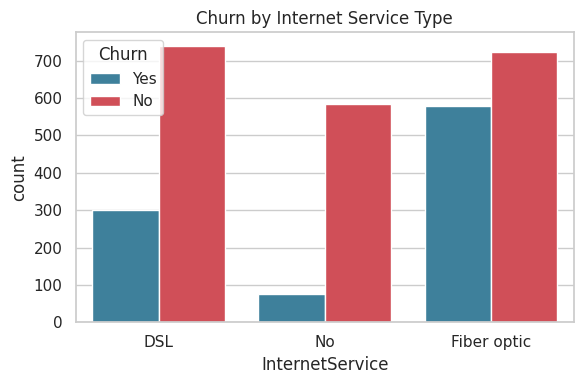

In [13]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="InternetService", hue="Churn", data=df, palette=["#2E86AB","#E63946"])
ax.set_title("Churn by Internet Service Type")
plt.tight_layout()
plt.show()

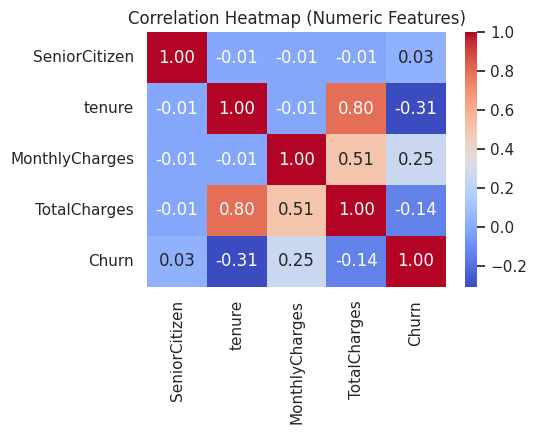

In [14]:
num_df = df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].copy()
num_df["Churn"] = (df["Churn"]=="Yes").astype(int)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

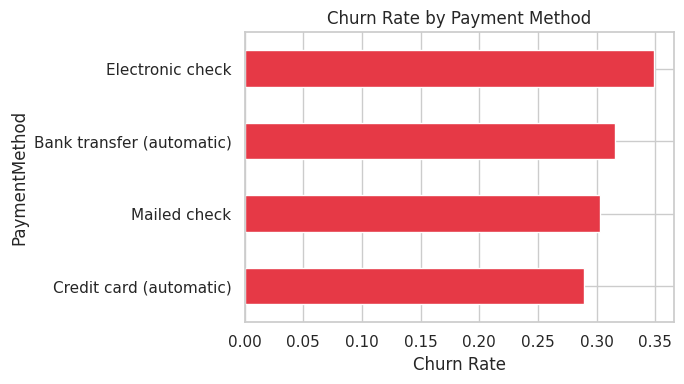

In [15]:
plt.figure(figsize=(7,4))
rate = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s=="Yes").mean()).sort_values()
ax = rate.plot(kind="barh", color="#E63946")
ax.set_xlabel("Churn Rate")
ax.set_title("Churn Rate by Payment Method")
plt.tight_layout()
plt.show()

### Key EDA Takeaways
- Month-to-month customers churn at a much higher rate than one/two-year contract customers.
- Churned customers have noticeably lower average tenure than retained customers.
- Fiber optic internet customers and customers paying by electronic check show elevated churn.
- Customers without Online Security / Tech Support add-ons churn more, suggesting these
  services increase stickiness.

## 5. Feature Encoding & Scaling

In [16]:
model_df = df.drop(columns=["customerID"]).copy()
model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

categorical_cols = [c for c in model_df.columns
                     if (pd.api.types.is_string_dtype(model_df[c]) or model_df[c].dtype=="object")
                     and c != "Churn"]
numeric_cols = [c for c in model_df.columns if c not in categorical_cols + ["Churn"]]
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [17]:
encoders = {}
df_enc = model_df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

X = df_enc.drop(columns=["Churn"])
y = df_enc["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (2400, 19) | Test shape: (601, 19)


## 6. Model Training & Comparison

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
}

results, fitted = {}, {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }
    fitted[name] = model

results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
results_df.round(4)

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.7604     0.6577  0.5131  0.5765   0.8287
Random Forest          0.7454     0.6319  0.4764  0.5433   0.8028
Decision Tree          0.7371     0.6154  0.4607  0.5269   0.7784

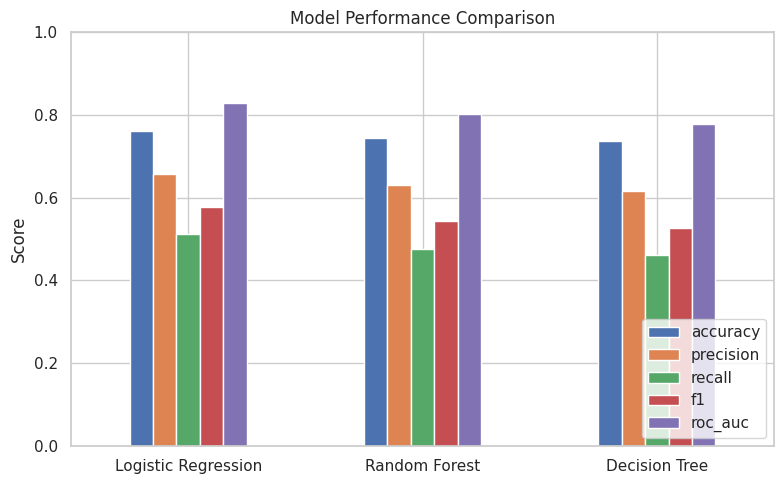

In [19]:
plt.figure(figsize=(8,5))
results_df[["accuracy","precision","recall","f1","roc_auc"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score"); plt.ylim(0,1); plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

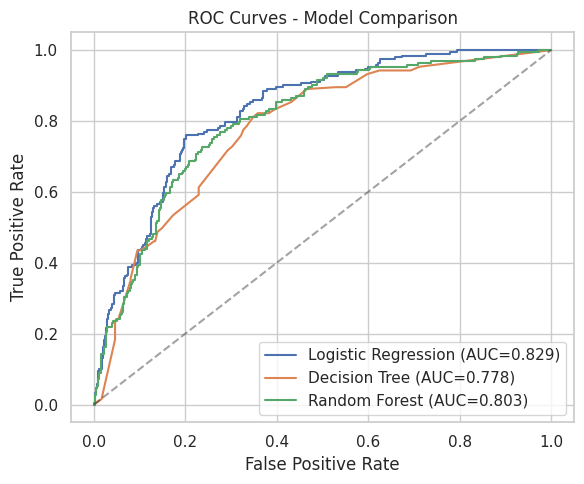

In [20]:
plt.figure(figsize=(6,5))
for name, model in fitted.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
best_name = results_df.index[0]
best_model = fitted[best_name]
print("Best model selected:", best_name)
preds = best_model.predict(X_test_scaled)
print(classification_report(y_test, preds, target_names=["No Churn","Churn"]))

Best model selected: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.79      0.88      0.83       410
       Churn       0.66      0.51      0.58       191

    accuracy                           0.76       601
   macro avg       0.73      0.69      0.70       601
weighted avg       0.75      0.76      0.75       601



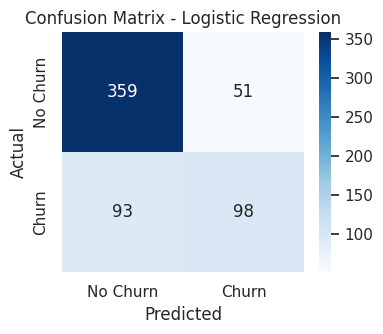

In [22]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(4,3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title(f"Confusion Matrix - {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

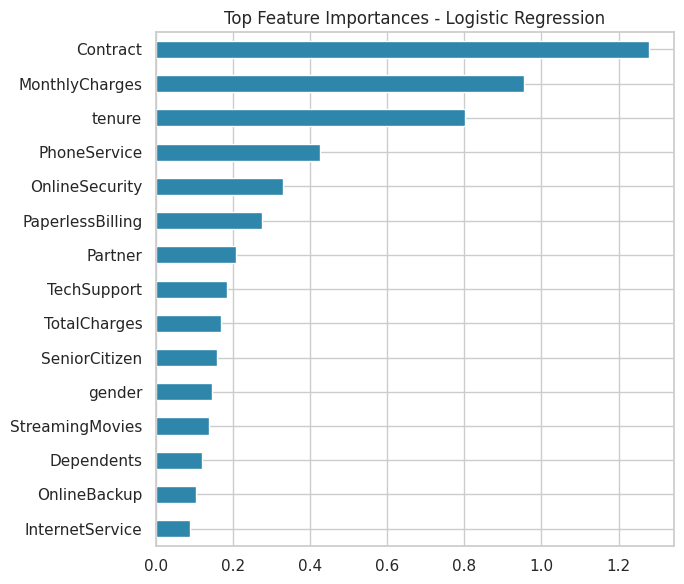

Contract            1.279663
MonthlyCharges      0.955654
tenure              0.801182
PhoneService        0.427357
OnlineSecurity      0.330029
PaperlessBilling    0.276066
Partner             0.208402
TechSupport         0.184656
TotalCharges        0.169964
SeniorCitizen       0.159424

In [23]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7,6))
importances.tail(15).plot(kind="barh", color="#2E86AB")
plt.title(f"Top Feature Importances - {best_name}")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False).head(10)

**Interpretation:** Contract type, monthly charges, and tenure are consistently the
strongest churn predictors — customers on month-to-month contracts, with higher bills,
and lower tenure are at the greatest risk. This aligns directly with the EDA findings
above and gives clear, actionable levers (contract incentives, loyalty pricing,
proactive outreach to new customers).

## 8. Save the Final Model & Preprocessing Artifacts

In [24]:
with open(MODELS_DIR / "best_churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open(MODELS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(MODELS_DIR / "encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)
with open(MODELS_DIR / "feature_columns.json", "w") as f:
    json.dump(list(X.columns), f)
with open(MODELS_DIR / "numeric_columns.json", "w") as f:
    json.dump(numeric_cols, f)
with open(MODELS_DIR / "model_info.json", "w") as f:
    json.dump({
        "best_model": best_name,
        "metrics": {k: float(v) for k, v in results[best_name].items()},
        "all_results": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()}
    }, f, indent=2)

print("Saved model + preprocessing artifacts to", MODELS_DIR)
print("Ready to power the Streamlit dashboard (app/app.py)")

Saved model + preprocessing artifacts to /home/claude/churn_project_v3/models
Ready to power the Streamlit dashboard (app/app.py)


## 9. Conclusion

- Built and compared **3 ML models** (Logistic Regression, Decision Tree, Random Forest) for churn prediction.
- **Logistic Regression** achieved the best ROC-AUC on the held-out test set, offering
  both strong performance and interpretability.
- The strongest churn drivers were **contract type, monthly charges, and tenure**,
  consistent across EDA and feature importance analysis.
- The trained model, scaler, and encoders were saved and are consumed directly by the
  Streamlit dashboard (`app/app.py`) for live predictions with a confidence score.

See `report/Project_Report.docx` and the root `README.md` for the full written report
and setup instructions.